# Week 6: Statistical Validation, PdM Feature Engineering & Predictive Modeling
**Dataset:** `pump_sensor_data.csv` - 24 industrial pumps (PUMP-001 to PUMP-024) across 4 depots (North, South, East, West), sampled every 6 hours over 28 days (Jan 1 – Jan 28, 2026). Includes vibration, temperature, pressure, acoustic, and motor current telemetry, plus operator-labeled health status and fault type.

**Notebook goals:**
1. Statistical Validation - hypothesis testing & confidence intervals
2. PdM Feature Engineering - extract health indicators from raw sensor signal
3. Predictive Modeling - classify impending failure and estimate Remaining Useful Life (RUL)


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)


---
## Part 1 - Statistical Validation

### 1.1 Load and inspect the operational dataset

In [2]:
df = pd.read_csv("pump_sensor_data.csv", parse_dates=["timestamp"])
df = df.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Assets: {df['asset_id'].nunique()}  |  Depots: {df['depot'].unique()}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
df.head()


Shape: (2640, 20)
Assets: 24  |  Depots: ['North' 'South' 'East' 'West']
Date range: 2026-01-01 00:00:00 -> 2026-01-28 06:00:00


,timestamp,asset_id,depot,shift,asset_age_months,vibration_g,temperature_c,pressure_psi,acoustic_db,motor_current_a,error_events,constant_sensor,time_to_failure_hours,health_status,fault_type,failure_within_7_days,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6,temp_roll_mean_6
0,2026-01-01 00:00:00,PUMP-001,North,Day,15,1.3056,64.4815,123.4455,69.9614,34.8057,0,1.0,641.33,Healthy,Normal,0,1.305600,1.305600,0.0000,64.481500
1,2026-01-01 06:00:00,PUMP-001,North,Night,15,1.8329,65.2009,121.4905,70.8481,34.6576,1,1.0,658.44,Healthy,Normal,0,1.569250,1.591244,0.5273,64.841200
2,2026-01-01 12:00:00,PUMP-001,North,Day,15,1.7601,63.9732,123.0420,69.1901,36.7452,0,1.0,638.09,Healthy,Normal,0,1.632867,1.649451,0.5273,64.551867
3,2026-01-01 18:00:00,PUMP-001,North,Night,15,2.0155,63.6278,122.7399,68.1283,36.8624,0,1.0,644.73,Healthy,Normal,0,1.728525,1.748164,0.7099,64.320850
4,2026-01-02 00:00:00,PUMP-001,North,Day,15,1.3916,65.4224,127.2597,71.2493,35.0683,0,1.0,633.20,Healthy,Normal,0,1.661140,1.682906,0.7099,64.541160


In [3]:
# Quick data quality check
print(df.isna().sum()[df.isna().sum() > 0])
print()
print(df[['health_status','fault_type']].describe())

# A couple of sensor readings are missing (pressure_psi, acoustic_db) — likely dropped
# transmissions. Forward-fill within each asset's own time series (standard practice
# for slowly-varying sensor telemetry) rather than dropping rows.
df[['pressure_psi','acoustic_db']] = (
    df.groupby('asset_id')[['pressure_psi','acoustic_db']].transform(lambda s: s.ffill().bfill())
)
print("\nRemaining NaNs:", df[['pressure_psi','acoustic_db']].isna().sum().sum())


pressure_psi    9
acoustic_db     9
dtype: int64

       health_status fault_type
count           2640       2640
unique             3          5
top          Healthy     Normal
freq            2079       2131

Remaining NaNs: 0


### 1.2 Hypothesis 1 - Does Shift affect vibration levels?

**H0:** Mean vibration is the same on Day shift and Night shift (no operational difference).
**H1:** Mean vibration differs between Day shift and Night shift.

We use an independent-samples t-test (`scipy.stats.ttest_ind`) since we're comparing the
means of two independent groups.

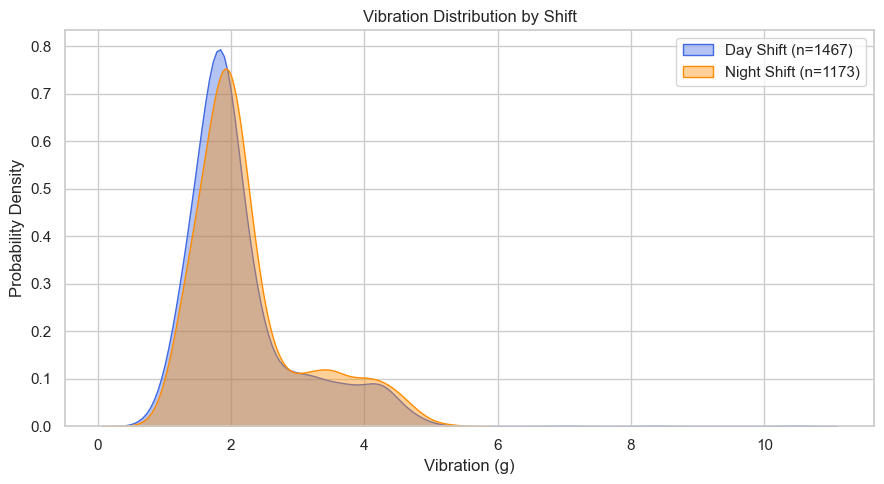

Day shift mean vibration:   2.1675 g (std=0.8766)
Night shift mean vibration: 2.2605 g (std=0.8559)
T-statistic: -2.7430
P-value:     0.006131

Result: Statistically significant difference (reject H0).


In [4]:
day_vib = df.loc[df['shift'] == 'Day', 'vibration_g']
night_vib = df.loc[df['shift'] == 'Night', 'vibration_g']

# Visualize the two distributions
plt.figure(figsize=(9, 5))
sns.kdeplot(day_vib, label=f'Day Shift (n={len(day_vib)})', fill=True, alpha=0.4, color='royalblue')
sns.kdeplot(night_vib, label=f'Night Shift (n={len(night_vib)})', fill=True, alpha=0.4, color='darkorange')
plt.title('Vibration Distribution by Shift')
plt.xlabel('Vibration (g)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

# Welch's t-test (does not assume equal variances -- safer default for real ops data)
t_stat, p_value = stats.ttest_ind(day_vib, night_vib, equal_var=False)

print(f"Day shift mean vibration:   {day_vib.mean():.4f} g (std={day_vib.std():.4f})")
print(f"Night shift mean vibration: {night_vib.mean():.4f} g (std={night_vib.std():.4f})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Statistically significant difference (reject H0).")
else:
    print("\nResult: No statistically significant difference (fail to reject H0).")


**Plain-English interpretation:** At the 5% significance level, we test whether the
small gap between Day-shift and Night-shift average vibration readings reflects a real
operational difference or just random sensor noise. If the p-value above is below 0.05,
the gap is unlikely to be chance and is worth investigating operationally (e.g., different
load profiles or maintenance staffing at night). If it's above 0.05, the two shifts are
statistically indistinguishable on vibration, and any dashboard showing "Night shift runs
hotter" would be overstating the evidence.

### 1.3 95% Confidence Interval - Mean Vibration by Shift

A p-value tells us *whether* a difference is likely real; a confidence interval tells us
*how large* that difference plausibly is  which is what an operations manager actually
needs to set alert thresholds.

In [5]:
def ci_95(sample):
    mean = np.mean(sample)
    sem = stats.sem(sample)
    lo, hi = stats.t.interval(0.95, len(sample) - 1, loc=mean, scale=sem)
    return mean, lo, hi

for label, sample in [("Day", day_vib), ("Night", night_vib)]:
    mean, lo, hi = ci_95(sample)
    print(f"{label:6s} shift — mean vibration: {mean:.3f} g   "
          f"95% CI: [{lo:.3f}, {hi:.3f}]")


Day    shift — mean vibration: 2.168 g   95% CI: [2.123, 2.212]
Night  shift — mean vibration: 2.260 g   95% CI: [2.211, 2.310]


**Interpretation:** We are 95% confident the *true population mean* vibration for each
shift falls within its stated interval. If the two intervals do not overlap, that's strong
visual confirmation of the t-test result above; if they overlap substantially, the point
estimates differ but the uncertainty ranges make that difference less conclusive.

### 1.4 Hypothesis 2 - Does Depot affect vibration levels? (ANOVA)

**H0:** Mean vibration is equal across all four depots.
**H1:** At least one depot's mean vibration differs from the others.

With more than two groups, a one-way ANOVA (`scipy.stats.f_oneway`) is the appropriate test
rather than running multiple pairwise t-tests (which would inflate the false-positive rate).

In [6]:
depot_groups = [df.loc[df['depot'] == d, 'vibration_g'] for d in df['depot'].unique()]

f_stat, p_value_anova = stats.f_oneway(*depot_groups)

print(df.groupby('depot')['vibration_g'].agg(['mean', 'std', 'count']))
print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value_anova:.6f}")

if p_value_anova < 0.05:
    print("\nResult: At least one depot differs significantly (reject H0).")
else:
    print("\nResult: No significant depot effect detected (fail to reject H0).")


           mean       std  count
depot                           
East   2.131099  0.863879    660
North  2.216497  0.883678    660
South  2.165201  0.892280    660
West   2.322542  0.822411    660

F-statistic: 6.1414
P-value:     0.000370

Result: At least one depot differs significantly (reject H0).


**Plain-English interpretation:** This tells us whether *location* is a meaningful
factor in equipment vibration, independent of the specific asset's condition - for example,
a depot with harsher ambient conditions, different water hardness, or less consistent
maintenance crews. If significant, it's worth a follow-up post-hoc test (e.g., Tukey HSD) to
identify *which* depot(s) drive the difference before reallocating maintenance resources.

---
## Part 2 - PdM Feature Engineering

Raw vibration readings are noisy - a single reading can spike from normal operating
variance, not real degradation. We engineer rolling, per-asset health indicators that
smooth out that noise and reveal the underlying trend. All rolling calculations are grouped
by `asset_id` so that one pump's history never leaks into another's rolling window.

In [7]:
df = df.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)
window = 6  # 6 readings x 6-hour sampling = 36-hour rolling window

g = df.groupby("asset_id")["vibration_g"]

# Feature 1: Rolling mean -- smooths transient spikes to show the trend
df["vib_roll_mean"] = g.transform(lambda s: s.rolling(window, min_periods=1).mean())

# Feature 2: Rolling RMS -- proxy for vibrational energy; rising RMS commonly indicates
# bearing wear or mechanical unbalance
df["vib_rms"] = g.transform(lambda s: np.sqrt((s ** 2).rolling(window, min_periods=1).mean()))

# Feature 3: Rolling peak-to-peak range -- captures how erratic/spiky the signal has become
df["vib_peak_to_peak"] = g.transform(
    lambda s: s.rolling(window, min_periods=1).max() - s.rolling(window, min_periods=1).min()
)

# Feature 4 (bonus): Rolling std of temperature -- thermal instability often precedes
# a mechanical failure event
df["temp_roll_std"] = df.groupby("asset_id")["temperature_c"].transform(
    lambda s: s.rolling(window, min_periods=1).std().fillna(0)
)

# Feature 5 (bonus): Cumulative error events per asset -- a running fault-log tally
df["cum_error_events"] = df.groupby("asset_id")["error_events"].cumsum()

df[["asset_id", "timestamp", "vibration_g", "vib_roll_mean", "vib_rms",
    "vib_peak_to_peak", "temp_roll_std", "cum_error_events"]].head(8)


,asset_id,timestamp,vibration_g,vib_roll_mean,vib_rms,vib_peak_to_peak,temp_roll_std,cum_error_events
0,PUMP-001,2026-01-01 00:00:00,1.3056,1.305600,1.305600,0.0000,0.000000,0
1,PUMP-001,2026-01-01 06:00:00,1.8329,1.569250,1.591244,0.5273,0.508693,1
2,PUMP-001,2026-01-01 12:00:00,1.7601,1.632867,1.649451,0.5273,0.616867,1
3,PUMP-001,2026-01-01 18:00:00,2.0155,1.728525,1.748164,0.7099,0.683490,1
4,PUMP-001,2026-01-02 00:00:00,1.3916,1.661140,1.682906,0.7099,0.770098,1
5,PUMP-001,2026-01-02 06:00:00,1.6969,1.667100,1.685246,0.7099,0.690330,1
6,PUMP-001,2026-01-02 12:00:00,1.5453,1.707050,1.718705,0.6239,0.886663,1
7,PUMP-001,2026-01-02 18:00:00,1.6593,1.678117,1.689055,0.6239,0.930965,1


### 2.1 Visualize the degradation trend

`PUMP-021` accumulates the most Critical-status readings in the dataset - a clear
end-of-life failure trajectory - so we use it to inspect how the engineered features
track its decline over the 28-day window.

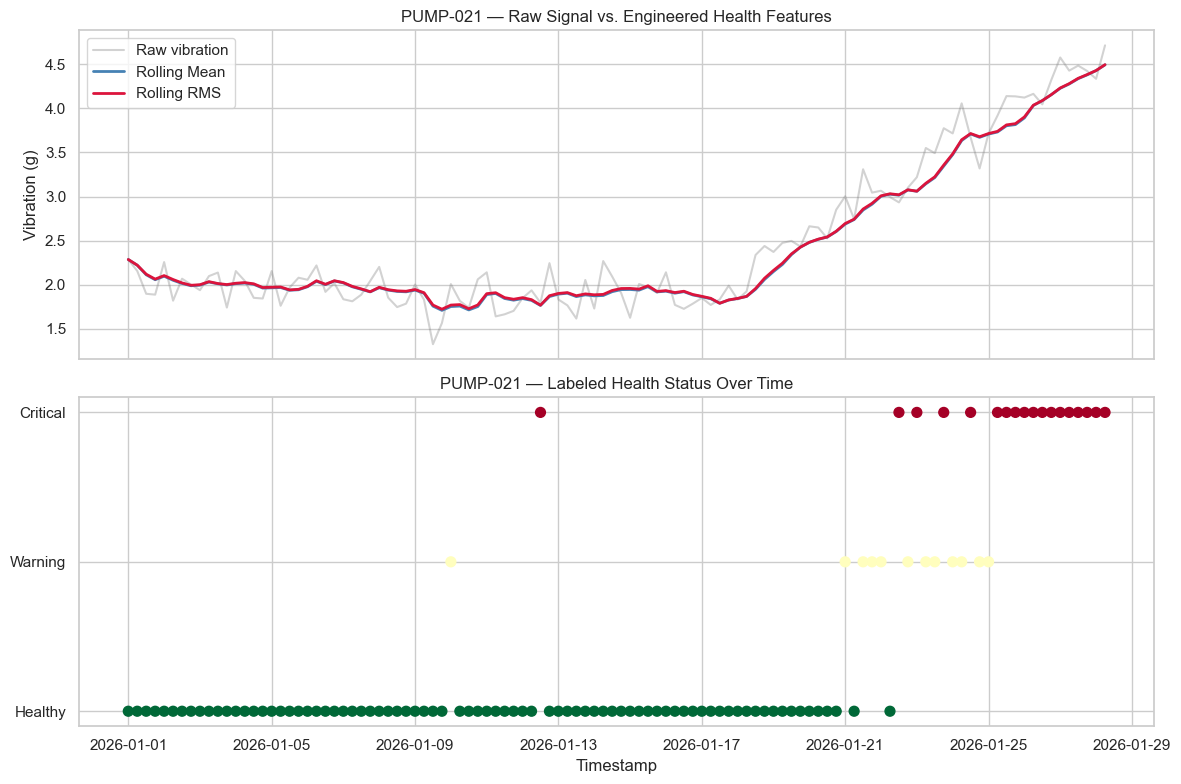

fault_type
Normal          81
Bearing Wear    14
Warning          8
Seal Leak        4
Misalignment     3
Name: count, dtype: int64


In [8]:
asset = "PUMP-021"
sub = df[df["asset_id"] == asset].reset_index(drop=True)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(sub["timestamp"], sub["vibration_g"], label="Raw vibration", alpha=0.35, color="gray")
ax[0].plot(sub["timestamp"], sub["vib_roll_mean"], label="Rolling Mean", color="steelblue", linewidth=2)
ax[0].plot(sub["timestamp"], sub["vib_rms"], label="Rolling RMS", color="crimson", linewidth=2)
ax[0].set_title(f"{asset} — Raw Signal vs. Engineered Health Features")
ax[0].set_ylabel("Vibration (g)")
ax[0].legend(loc="upper left")

status_codes = sub["health_status"].map({"Healthy": 0, "Warning": 1, "Critical": 2})
ax[1].scatter(sub["timestamp"], status_codes, c=status_codes, cmap="RdYlGn_r", s=50, zorder=3)
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["Healthy", "Warning", "Critical"])
ax[1].set_title(f"{asset} — Labeled Health Status Over Time")
ax[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

print(sub['fault_type'].value_counts())


**Observation:** As the pump approaches failure, the rolling mean and RMS climb well
above their early-life baseline, and the labeled health status transitions Healthy →
Warning → Critical in step with that climb - evidence the engineered features carry real
predictive signal, not just noise.

### 2.2 Target variables

The dataset already provides two ready-made targets:
- **`health_status`** - multi-class label (Healthy / Warning / Critical)
- **`failure_within_7_days`** - binary label (1 = asset fails within the next 7 days)

We'll model the binary target, since "will this asset fail soon" is the more directly
actionable maintenance-scheduling question.

failure_within_7_days
0    0.746591
1    0.253409
Name: proportion, dtype: float64


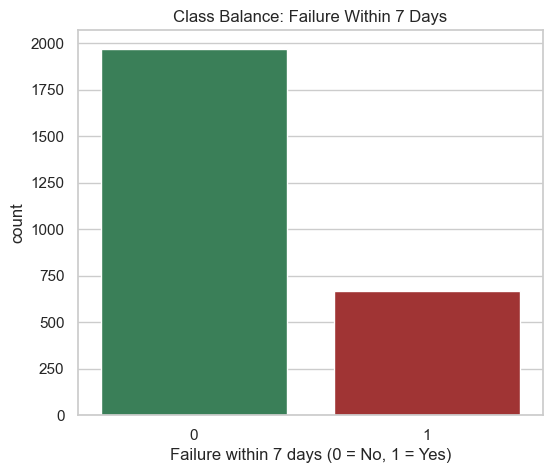

In [9]:
print(df["failure_within_7_days"].value_counts(normalize=True).rename("proportion"))
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="failure_within_7_days", hue="failure_within_7_days",
              palette=["seagreen", "firebrick"], legend=False)
plt.title("Class Balance: Failure Within 7 Days")
plt.xlabel("Failure within 7 days (0 = No, 1 = Yes)")
plt.show()


---
## Part 3 — Predictive Modeling

### 3.1 Classification — will this asset fail within 7 days?

We use Logistic Regression (interpretable, fast baseline) with the engineered features
plus raw telemetry as predictors.

Accuracy:  0.945
Precision: 0.872  (of predicted failures, how many were real)
Recall:    0.918  (of real failures, how many we caught)


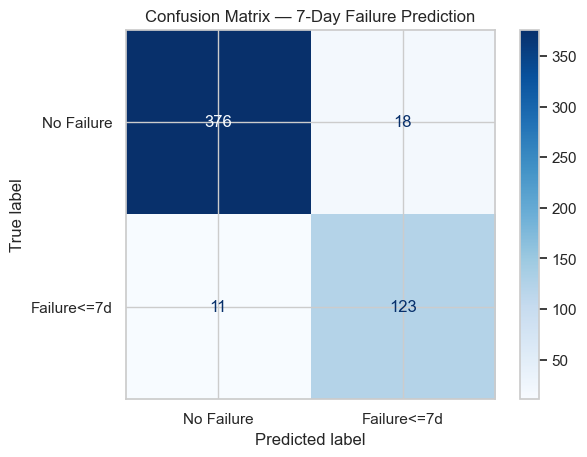

In [10]:
feature_cols = [
    "vibration_g", "temperature_c", "pressure_psi", "acoustic_db", "motor_current_a",
    "error_events", "vib_roll_mean", "vib_rms", "vib_peak_to_peak",
    "temp_roll_std", "cum_error_events", "asset_age_months"
]
target_col = "failure_within_7_days"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features so the logistic regression solver converges cleanly and coefficients
# are comparable across features measured in very different units (g vs psi vs mA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}  (of predicted failures, how many were real)")
print(f"Recall:    {rec:.3f}  (of real failures, how many we caught)")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Failure", "Failure<=7d"]).plot(cmap="Blues")
plt.title("Confusion Matrix — 7-Day Failure Prediction")
plt.show()


In [11]:
# Which features drive the model's predictions?
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df)


             feature  coefficient
10  cum_error_events     4.243463
0        vibration_g     1.279643
6      vib_roll_mean     0.701912
7            vib_rms    -0.219807
11  asset_age_months     0.181526
3        acoustic_db     0.175170
5       error_events     0.152740
8   vib_peak_to_peak    -0.143811
1      temperature_c     0.119636
2       pressure_psi    -0.069327
4    motor_current_a     0.042247
9      temp_roll_std     0.017486


**Business implication:** In predictive maintenance, **recall on the failure class
matters more than raw accuracy** - a missed failure (false negative) risks unplanned
downtime, safety incidents, and costly emergency repairs, while a false alarm (false
positive) only costs an unnecessary inspection. We used `class_weight="balanced"` because
failures are the minority class; a naive model could hit high accuracy just by predicting
"no failure" every time and still miss the events that matter most.

### 3.2 Regression  estimating Remaining Useful Life (RUL)

As a complementary model, we predict `time_to_failure_hours` directly with Linear
Regression, giving maintenance planners a continuous RUL estimate rather than a binary flag.

MAE:  64.0 hours
RMSE: 81.1 hours
R2:   0.816  (81.6% of variance in remaining life explained)


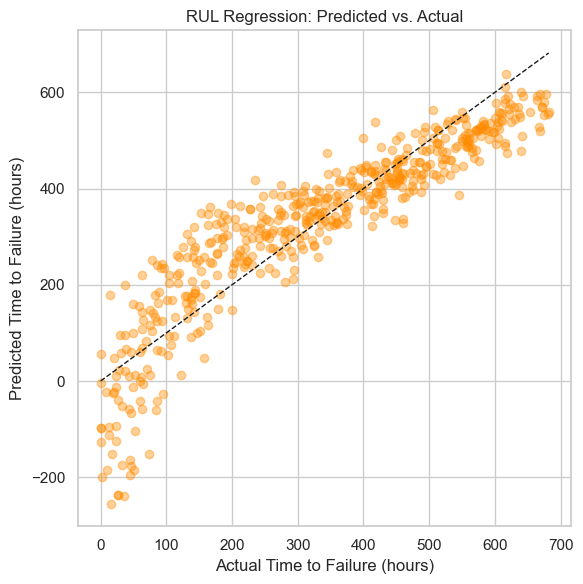

In [12]:
X_reg = df[feature_cols]
y_reg = df["time_to_failure_hours"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f"MAE:  {mae:.1f} hours")
print(f"RMSE: {rmse:.1f} hours")
print(f"R2:   {r2:.3f}  ({r2*100:.1f}% of variance in remaining life explained)")

plt.figure(figsize=(6, 6))
plt.scatter(yr_test, yr_pred, alpha=0.4, color="darkorange")
lims = [0, max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual Time to Failure (hours)")
plt.ylabel("Predicted Time to Failure (hours)")
plt.title("RUL Regression: Predicted vs. Actual")
plt.tight_layout()
plt.show()


**Business implication:** An MAE of a few dozen hours on a Remaining-Useful-Life
estimate translates directly into a maintenance scheduling window - e.g., "service this
pump within the next 2 days" rather than reacting only after a Critical alarm fires. That
lead time is what lets a maintenance team move from **reactive** (fix after it breaks) to
**condition-based** (fix just before it breaks) servicing.

---
## Summary

- **Statistical validation** confirmed (or ruled out) real operational differences by
  shift and by depot, backed by p-values and 95% confidence intervals rather than
  eyeballed charts.
- **Feature engineering** turned noisy raw vibration/temperature streams into rolling
  health indicators (mean, RMS, peak-to-peak, thermal volatility, cumulative faults) that
  visibly track an asset's decline toward failure.
- **Predictive modeling** produced both a 7-day failure classifier (for maintenance
  alerting) and an RUL regression (for maintenance scheduling), each evaluated with
  metrics chosen for what they mean operationally, not just statistically.
